# Sprint 2 - Datos geoespaciales

Se procesan los tres candidatos con las mismas fuentes y la misma resolución:

- Dynamic World - agosto 2024
- Copernicus DEM GLO-30
- Pendiente en grados
- Resolución de salida: 50 m

## 1. Librerías y conexión

In [1]:
!pip install rasterio -q

import os
import json
import requests
import ee
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from google.colab import auth

auth.authenticate_user()
ee.Initialize(project="incendioforestal-509918")

os.makedirs("data/raw/dem", exist_ok=True)
os.makedirs("data/raw/vegetation", exist_ok=True)

print("Conexion a Earth Engine correcta.")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Conexion a Earth Engine correcta.


## 2. Regiones

In [2]:
regiones = {
    "ucayali": {
        "nombre": "Ucayali",
        "bbox": [-74.65, -8.45, -74.45, -8.30],
        "crs": "EPSG:32718"
    },
    "madre_de_dios": {
        "nombre": "Madre de Dios",
        "bbox": [-69.35, -12.70, -69.05, -12.45],
        "crs": "EPSG:32719"
    },
    "san_martin": {
        "nombre": "San Martin",
        "bbox": [-76.50, -7.20, -76.20, -6.90],
        "crs": "EPSG:32718"
    }
}

fecha_inicio = "2024-08-01"
fecha_fin = "2024-09-01"
resolucion = 50

for clave, datos in regiones.items():
    print(datos["nombre"], datos["bbox"])

Ucayali [-74.65, -8.45, -74.45, -8.3]
Madre de Dios [-69.35, -12.7, -69.05, -12.45]
San Martin [-76.5, -7.2, -76.2, -6.9]


## 3. Copernicus DEM

In [3]:
coleccion_dem = ee.ImageCollection("COPERNICUS/DEM/GLO30_2024_1")
proyeccion_dem = coleccion_dem.first().select("DEM").projection()

dem = (
    coleccion_dem
    .mosaic()
    .setDefaultProjection(proyeccion_dem)
    .select("DEM")
    .rename("DEM")
    .toFloat()
)

pendiente = (
    ee.Terrain.slope(dem)
    .rename("slope_deg")
    .toFloat()
)

print("DEM y pendiente preparados.")

DEM y pendiente preparados.


## 4. Funciones para guardar los raster

In [5]:
def descargar_tif(imagen, region, ruta, crs, remuestreo=None):
    if remuestreo is not None:
        imagen = imagen.resample(remuestreo)

    parametros = {
        "region": region,
        "scale": resolucion,
        "crs": crs,
        "format": "GEO_TIFF"
    }

    url = imagen.clip(region).getDownloadURL(parametros)
    respuesta = requests.get(url, timeout=120)
    respuesta.raise_for_status()

    with open(ruta, "wb") as archivo:
        archivo.write(respuesta.content)


def leer_tif(ruta, categoria=False):
    with rasterio.open(ruta) as src:
        matriz = src.read(1)

    if categoria:
        return matriz.astype(np.uint8)

    return matriz.astype(np.float32)

## 5. Procesar las tres regiones

In [6]:
resultados = {}

for clave, datos in regiones.items():
    print("\nProcesando", datos["nombre"])

    region = ee.Geometry.Rectangle(datos["bbox"])

    coleccion_dw = (
        ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
        .filterBounds(region)
        .filterDate(fecha_inicio, fecha_fin)
    )

    cantidad_dw = coleccion_dw.size().getInfo()

    vegetacion = (
        coleccion_dw
        .select("label")
        .mode()
        .rename("label")
        .unmask(255)
        .toUint8()
    )

    ruta_dem = f"data/raw/dem/{clave}_dem_50m.tif"
    ruta_slope = f"data/raw/dem/{clave}_slope_deg_50m.tif"
    ruta_veg = f"data/raw/vegetation/{clave}_vegetacion_2024_50m.tif"

    descargar_tif(dem, region, ruta_dem, datos["crs"], "bilinear")
    descargar_tif(pendiente, region, ruta_slope, datos["crs"], "bilinear")
    descargar_tif(vegetacion, region, ruta_veg, datos["crs"])

    matriz_dem = leer_tif(ruta_dem)
    matriz_slope = leer_tif(ruta_slope)
    matriz_veg = leer_tif(ruta_veg, categoria=True)

    np.save(f"data/raw/dem/{clave}_dem_50m.npy", matriz_dem)
    np.save(f"data/raw/dem/{clave}_slope_deg_50m.npy", matriz_slope)
    np.save(f"data/raw/vegetation/{clave}_vegetacion_2024_50m.npy", matriz_veg)

    resultados[clave] = {
        "nombre": datos["nombre"],
        "dem": matriz_dem,
        "slope": matriz_slope,
        "veg": matriz_veg,
        "imagenes_dw": cantidad_dw
    }

    print("DEM:", matriz_dem.shape)
    print("Pendiente:", matriz_slope.shape)
    print("Vegetacion:", matriz_veg.shape)
    print("Imagenes Dynamic World:", cantidad_dw)


Procesando Ucayali
DEM: (333, 442)
Pendiente: (333, 442)
Vegetacion: (333, 442)
Imagenes Dynamic World: 6

Procesando Madre de Dios
DEM: (554, 653)
Pendiente: (554, 653)
Vegetacion: (554, 653)
Imagenes Dynamic World: 11

Procesando San Martin
DEM: (666, 666)
Pendiente: (666, 666)
Vegetacion: (666, 666)
Imagenes Dynamic World: 8


## 6. Calcular los criterios

In [7]:
clases_dw = {
    0: "Agua",
    1: "Arboles",
    2: "Pasto",
    3: "Vegetacion inundada",
    4: "Cultivos",
    5: "Matorral",
    6: "Construido",
    7: "Suelo desnudo",
    8: "Nieve/hielo"
}

clases_combustibles = [1, 2, 4, 5]


def calcular_continuidad(matriz):
    validos = matriz != 255
    combustible = np.isin(matriz, clases_combustibles) & validos

    conexiones = 0
    posibles = 0

    izquierda = combustible[:, :-1]
    derecha_valida = validos[:, 1:]
    derecha = combustible[:, 1:]

    conexiones += np.sum(izquierda & derecha)
    posibles += np.sum(izquierda & derecha_valida)

    arriba = combustible[:-1, :]
    abajo_valido = validos[1:, :]
    abajo = combustible[1:, :]

    conexiones += np.sum(arriba & abajo)
    posibles += np.sum(arriba & abajo_valido)

    if posibles == 0:
        return 0.0

    return conexiones / posibles


resumen = []
detalle_clases = []

for clave, datos in resultados.items():
    dem_np = datos["dem"]
    slope_np = datos["slope"]
    veg_np = datos["veg"]

    validos = veg_np != 255
    total_validos = int(validos.sum())

    combustible = np.isin(veg_np, clases_combustibles) & validos
    combustible_pct = combustible.sum() / total_validos * 100
    agua_pct = ((veg_np == 0) & validos).sum() / total_validos * 100
    continuidad = calcular_continuidad(veg_np)

    resumen.append({
        "region": datos["nombre"],
        "imagenes_dynamic_world": datos["imagenes_dw"],
        "combustible_pct": round(float(combustible_pct), 2),
        "continuidad": round(float(continuidad), 3),
        "agua_pct": round(float(agua_pct), 2),
        "elevacion_min_m": round(float(np.nanmin(dem_np)), 2),
        "elevacion_max_m": round(float(np.nanmax(dem_np)), 2),
        "pendiente_media_deg": round(float(np.nanmean(slope_np)), 2),
        "pendiente_std_deg": round(float(np.nanstd(slope_np)), 2)
    })

    for clase, nombre in clases_dw.items():
        cantidad = int(((veg_np == clase) & validos).sum())
        porcentaje = cantidad / total_validos * 100

        detalle_clases.append({
            "region": datos["nombre"],
            "clase": clase,
            "tipo": nombre,
            "pixeles": cantidad,
            "porcentaje": round(float(porcentaje), 2)
        })


df_resumen = pd.DataFrame(resumen)
df_clases = pd.DataFrame(detalle_clases)

display(df_resumen)
display(df_clases)

,region,imagenes_dynamic_world,combustible_pct,continuidad,agua_pct,elevacion_min_m,elevacion_max_m,pendiente_media_deg,pendiente_std_deg
0,Ucayali,6,63.45,0.959,8.99,136.0,176.88,2.17,1.98
1,Madre de Dios,11,90.03,0.988,5.26,164.0,278.27,4.55,3.42
2,San Martin,8,90.46,0.980,4.32,210.0,938.70,10.70,7.53


,region,clase,tipo,pixeles,porcentaje
0,Ucayali,0,Agua,13228,8.99
1,Ucayali,1,Arboles,67789,46.06
2,Ucayali,2,Pasto,6090,4.14
3,Ucayali,3,Vegetacion inundada,400,0.27
4,Ucayali,4,Cultivos,7357,5.00
5,Ucayali,5,Matorral,12155,8.26
6,Ucayali,6,Construido,36356,24.70
7,Ucayali,7,Suelo desnudo,3811,2.59
8,Ucayali,8,Nieve/hielo,0,0.00
9,Madre de Dios,0,Agua,19012,5.26


## 7. Guardar los resultados

In [8]:
resumen_veg = df_resumen[
    ["region", "imagenes_dynamic_world", "combustible_pct", "continuidad", "agua_pct"]
]

resumen_dem = df_resumen[
    ["region", "elevacion_min_m", "elevacion_max_m", "pendiente_media_deg", "pendiente_std_deg"]
]

resumen_veg.to_csv(
    "data/raw/vegetation/resumen_vegetacion_candidatos_2024.csv",
    index=False
)

df_clases.to_csv(
    "data/raw/vegetation/clases_dynamic_world_candidatos_2024.csv",
    index=False
)

resumen_dem.to_csv(
    "data/raw/dem/resumen_topografia_candidatos.csv",
    index=False
)

metadata_veg = {
    "dataset": "GOOGLE/DYNAMICWORLD/V1",
    "periodo": "2024-08-01/2024-08-31",
    "resolucion_salida_m": resolucion,
    "clases_combustibles": clases_combustibles
}

metadata_dem = {
    "dataset": "COPERNICUS/DEM/GLO30_2024_1",
    "resolucion_salida_m": resolucion,
    "unidad_pendiente": "grados"
}

with open(
    "data/raw/vegetation/metadata_dynamic_world_2024.json",
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(metadata_veg, archivo, indent=4, ensure_ascii=False)

with open(
    "data/raw/dem/metadata_copernicus_dem.json",
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(metadata_dem, archivo, indent=4, ensure_ascii=False)

print("Archivos de resumen guardados.")

Archivos de resumen guardados.


## 8. Gráficos

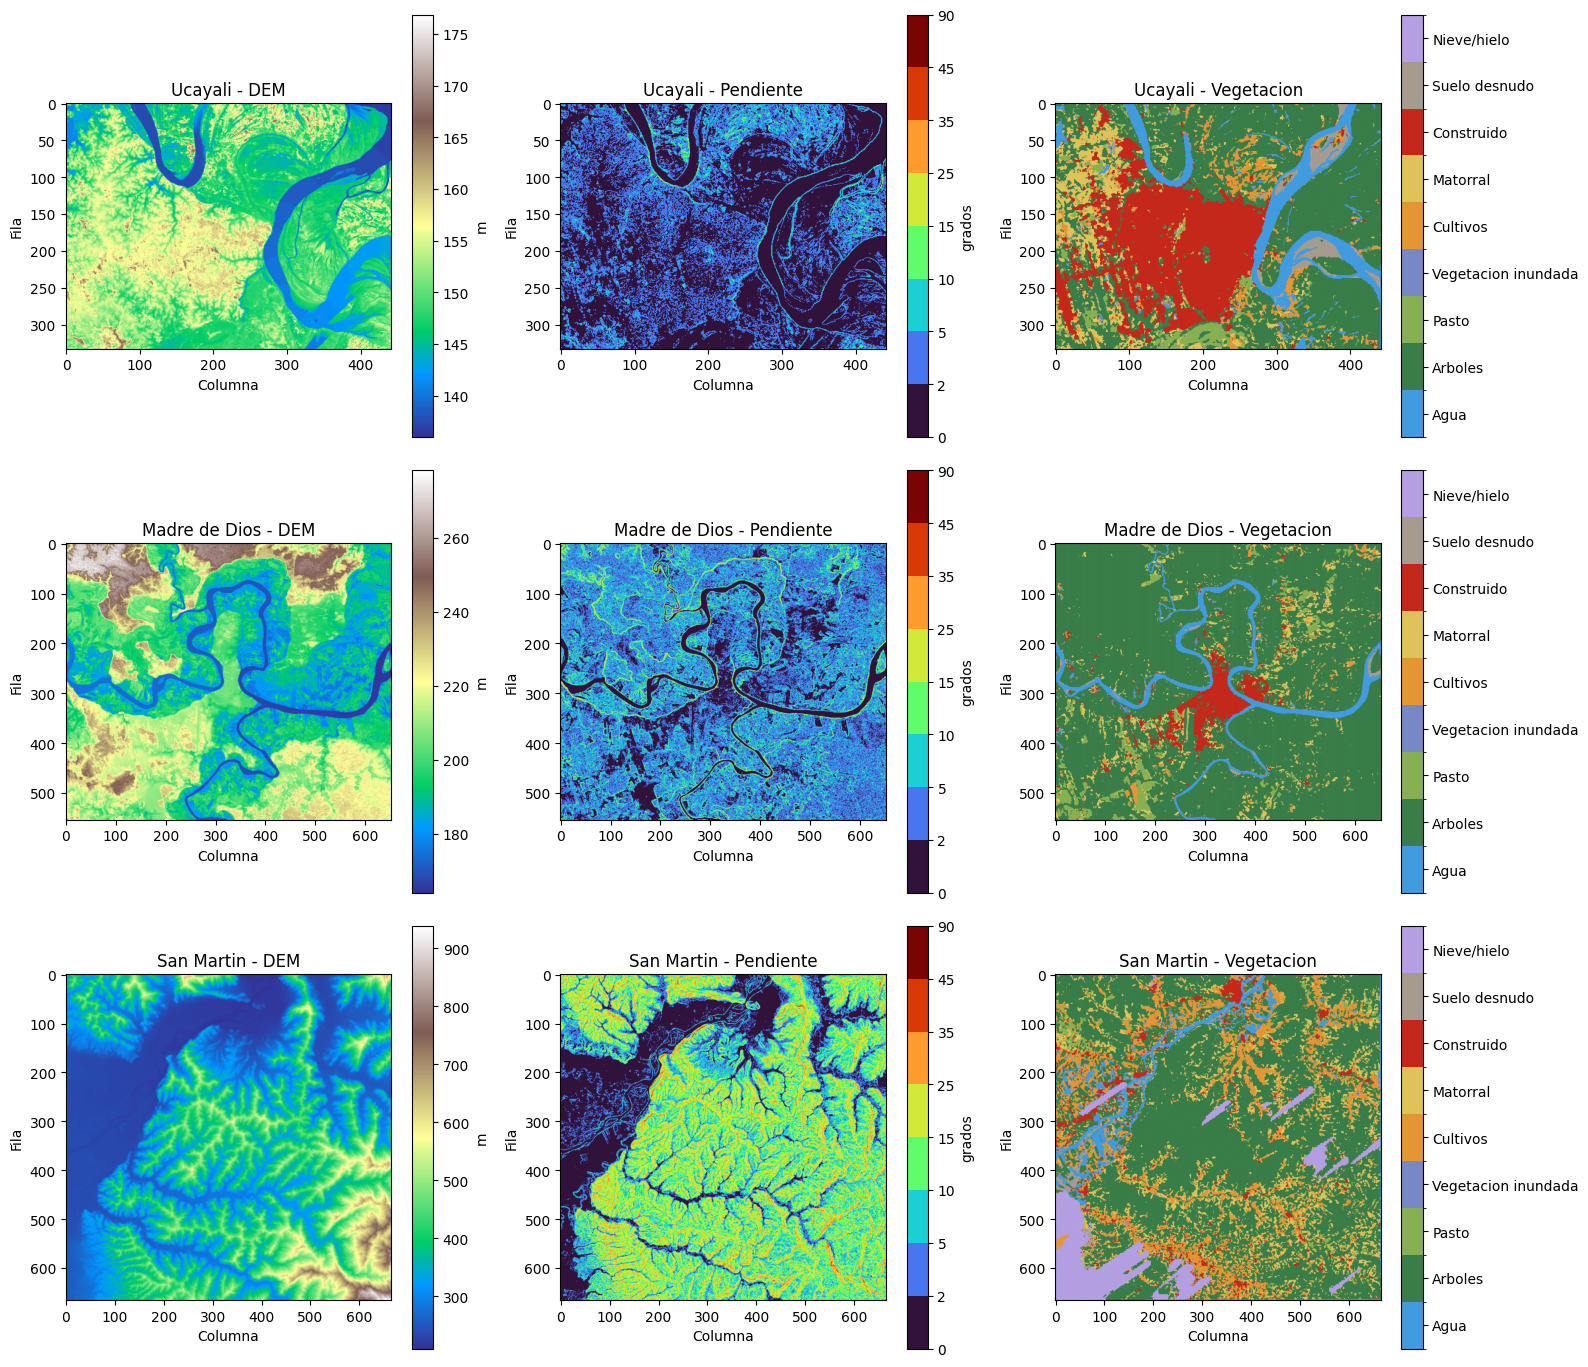

In [9]:
colores_veg = [
    "#419BDF",
    "#397D49",
    "#88B053",
    "#7A87C6",
    "#E49635",
    "#DFC35A",
    "#C4281B",
    "#A59B8F",
    "#B39FE1"
]

nombres_veg = [
    "Agua",
    "Arboles",
    "Pasto",
    "Vegetacion inundada",
    "Cultivos",
    "Matorral",
    "Construido",
    "Suelo desnudo",
    "Nieve/hielo"
]

cmap_veg = ListedColormap(colores_veg)
norm_veg = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5],
    cmap_veg.N
)

niveles_slope = [0, 2, 5, 10, 15, 25, 35, 45, 90]
cmap_slope = plt.get_cmap("turbo", len(niveles_slope) - 1)
norm_slope = BoundaryNorm(niveles_slope, cmap_slope.N)

fig, ejes = plt.subplots(3, 3, figsize=(16, 14))

for fila, clave in enumerate(regiones):
    datos = resultados[clave]

    img_dem = ejes[fila, 0].imshow(datos["dem"], cmap="terrain")
    ejes[fila, 0].set_title(datos["nombre"] + " - DEM")
    fig.colorbar(img_dem, ax=ejes[fila, 0], label="m")

    img_slope = ejes[fila, 1].imshow(
        datos["slope"],
        cmap=cmap_slope,
        norm=norm_slope
    )
    ejes[fila, 1].set_title(datos["nombre"] + " - Pendiente")
    fig.colorbar(
        img_slope,
        ax=ejes[fila, 1],
        ticks=niveles_slope,
        label="grados"
    )

    img_veg = ejes[fila, 2].imshow(
        datos["veg"],
        cmap=cmap_veg,
        norm=norm_veg
    )
    ejes[fila, 2].set_title(datos["nombre"] + " - Vegetacion")

    barra = fig.colorbar(
        img_veg,
        ax=ejes[fila, 2],
        ticks=range(9)
    )
    barra.ax.set_yticklabels(nombres_veg)

for ax in ejes.flat:
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")

plt.tight_layout()
plt.show()

## 9. Comprobación final

In [10]:
print("RESUMEN FINAL\n")

for clave, datos in resultados.items():
    print(datos["nombre"])
    print("  DEM:", datos["dem"].shape)
    print("  Pendiente:", datos["slope"].shape)
    print("  Vegetacion:", datos["veg"].shape)

print("\nArchivos CSV:")
print("  data/raw/vegetation/resumen_vegetacion_candidatos_2024.csv")
print("  data/raw/vegetation/clases_dynamic_world_candidatos_2024.csv")
print("  data/raw/dem/resumen_topografia_candidatos.csv")

RESUMEN FINAL

Ucayali
  DEM: (333, 442)
  Pendiente: (333, 442)
  Vegetacion: (333, 442)
Madre de Dios
  DEM: (554, 653)
  Pendiente: (554, 653)
  Vegetacion: (554, 653)
San Martin
  DEM: (666, 666)
  Pendiente: (666, 666)
  Vegetacion: (666, 666)

Archivos CSV:
  data/raw/vegetation/resumen_vegetacion_candidatos_2024.csv
  data/raw/vegetation/clases_dynamic_world_candidatos_2024.csv
  data/raw/dem/resumen_topografia_candidatos.csv


## 10. Subir al Drive del equipo

In [11]:
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
import google.auth

credenciales, _ = google.auth.default()

drive_service = build(
    "drive",
    "v3",
    credentials=credenciales
)

carpeta_dem = "1ecis9ic3U3nZsxDGdDxCOMX8gsaOFYmk"
carpeta_vegetacion = "1DSoCrvLOGzZT0P1r-f90_UgVbH9VSA0f"

print("Drive conectado.")

Drive conectado.


In [12]:
def subir_drive(ruta, carpeta_id):
    nombre = os.path.basename(ruta)

    consulta = (
        f"name='{nombre}' "
        f"and '{carpeta_id}' in parents "
        f"and trashed=false"
    )

    encontrados = drive_service.files().list(
        q=consulta,
        fields="files(id)"
    ).execute().get("files", [])

    media = MediaFileUpload(ruta, resumable=True)

    if encontrados:
        drive_service.files().update(
            fileId=encontrados[0]["id"],
            media_body=media
        ).execute()
        print("Actualizado:", nombre)
    else:
        drive_service.files().create(
            body={
                "name": nombre,
                "parents": [carpeta_id]
            },
            media_body=media,
            fields="id"
        ).execute()
        print("Subido:", nombre)

In [13]:
archivos_dem = [
    "data/raw/dem/resumen_topografia_candidatos.csv",
    "data/raw/dem/metadata_copernicus_dem.json"
]

archivos_veg = [
    "data/raw/vegetation/resumen_vegetacion_candidatos_2024.csv",
    "data/raw/vegetation/clases_dynamic_world_candidatos_2024.csv",
    "data/raw/vegetation/metadata_dynamic_world_2024.json"
]

for clave in regiones:
    archivos_dem += [
        f"data/raw/dem/{clave}_dem_50m.tif",
        f"data/raw/dem/{clave}_dem_50m.npy",
        f"data/raw/dem/{clave}_slope_deg_50m.tif",
        f"data/raw/dem/{clave}_slope_deg_50m.npy"
    ]

    archivos_veg += [
        f"data/raw/vegetation/{clave}_vegetacion_2024_50m.tif",
        f"data/raw/vegetation/{clave}_vegetacion_2024_50m.npy"
    ]

for archivo in archivos_dem:
    subir_drive(archivo, carpeta_dem)

for archivo in archivos_veg:
    subir_drive(archivo, carpeta_vegetacion)

print("Subida terminada.")

Subido: resumen_topografia_candidatos.csv
Subido: metadata_copernicus_dem.json
Subido: ucayali_dem_50m.tif
Subido: ucayali_dem_50m.npy
Subido: ucayali_slope_deg_50m.tif
Subido: ucayali_slope_deg_50m.npy
Subido: madre_de_dios_dem_50m.tif
Subido: madre_de_dios_dem_50m.npy
Subido: madre_de_dios_slope_deg_50m.tif
Subido: madre_de_dios_slope_deg_50m.npy
Subido: san_martin_dem_50m.tif
Subido: san_martin_dem_50m.npy
Subido: san_martin_slope_deg_50m.tif
Subido: san_martin_slope_deg_50m.npy
Subido: resumen_vegetacion_candidatos_2024.csv
Subido: clases_dynamic_world_candidatos_2024.csv
Subido: metadata_dynamic_world_2024.json
Subido: ucayali_vegetacion_2024_50m.tif
Subido: ucayali_vegetacion_2024_50m.npy
Subido: madre_de_dios_vegetacion_2024_50m.tif
Subido: madre_de_dios_vegetacion_2024_50m.npy
Subido: san_martin_vegetacion_2024_50m.tif
Subido: san_martin_vegetacion_2024_50m.npy
Subida terminada.
